# Analisi cyclictest
Grafici: jitter massimo per scenario, boxplot e distribuzione delle latenze, riepilogo (media/std/max/min) e jitter per thread.

In [1]:
%matplotlib ipympl

import json
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-darkgrid')
pd.options.display.float_format = '{:.3f}'.format





In [2]:
# Carica tutti i file JSON disponibili
BASE_DIR = Path('.')
json_files = sorted(BASE_DIR.glob('cyclic_*.json'))
print('Trovati', len(json_files), 'file:')
for f in json_files:
    print(' -', f.name)


Trovati 6 file:
 - cyclic_baseline_nopreempt_rt.json
 - cyclic_baseline_preempt_rt.json
 - cyclic_stress_100k_nopreempt_rt.json
 - cyclic_stress_100k_preempt_rt.json
 - cyclic_stress_1M_nopreempt_rt.json
 - cyclic_stress_1M_preempt_rt.json


In [3]:
# Normalizzazione nomi scenario e label leggibili
scenario_label_map = {
    'baseline_nopreempt_rt': 'Baseline No Preempt-RT',
    'baseline_preempt_rt': 'Baseline Preempt-RT',
    'stress_100k_nopreempt_rt': 'Stress 100k No Preempt-RT',
    'stress_100k_preempt_rt': 'Stress 100k Preempt-RT',
    'stress_1m_nopreempt_rt': 'Stress 1M No Preempt-RT',
    'stress_1m_preempt_rt': 'Stress 1M Preempt-RT',
}

def normalize_key(name: str) -> str:
    key = name.lower()
    key = key.replace('cyclic_', '')
    key = key.replace('stess', 'stress')
    key = key.replace('noprempt', 'nopreempt')
    key = key.replace('preemptrt', 'preempt_rt')
    key = key.replace('preempt-rt', 'preempt_rt')
    key = key.replace('nopreempt-rt', 'nopreempt_rt')
    key = key.replace('__', '_')
    return key

def prettify(scenario_key: str) -> str:
    key = normalize_key(scenario_key)
    if key in scenario_label_map:
        return scenario_label_map[key]
    return key.replace('_', ' ').title()


In [4]:
def load_json_hist(path: Path, scenario_key: str, scenario_label: str):
    data = json.loads(path.read_text())
    threads = data.get('thread', {})
    thread_rows, lat_rows = [], []
    for tid_str, info in threads.items():
        tid = int(tid_str)
        hist = {int(k): int(v) for k, v in (info.get('histogram') or {}).items()}
        lats = []
        for lat, cnt in hist.items():
            lats.extend([lat] * cnt)
        arr = np.array(lats, dtype=int)
        if arr.size:
            mean = float(arr.mean())
            std = float(arr.std())
            tmin = int(arr.min())
            tmax = int(arr.max())
            samples = int(arr.size)
            lat_rows.extend([(scenario_label, tid, int(v), scenario_key) for v in arr])
        else:
            mean = float(info.get('avg', np.nan))
            std = float('nan')
            tmin = int(info.get('min', np.nan)) if info.get('min') is not None else np.nan
            tmax = int(info.get('max', np.nan)) if info.get('max') is not None else np.nan
            samples = int(info.get('cycles', 0))
        thread_rows.append({
            'scenario_key': scenario_key,
            'scenario': scenario_label,
            'thread': tid,
            'min': tmin,
            'max': tmax,
            'mean': mean,
            'std': std,
            'samples': samples,
            'jitter': tmax - tmin if tmin == tmin and tmax == tmax else np.nan,
        })
    return thread_rows, lat_rows


In [5]:
# Costruzione DataFrame
thread_rows = []
latency_rows = []
for path in json_files:
    raw_key = path.stem.replace('cyclic_', '')
    scenario_key = normalize_key(raw_key)
    scenario_label = prettify(raw_key)
    trows, lrows = load_json_hist(path, scenario_key, scenario_label)
    thread_rows.extend(trows)
    latency_rows.extend(lrows)

thread_df = pd.DataFrame(thread_rows)
latency_df = pd.DataFrame(latency_rows, columns=['scenario', 'thread', 'latency', 'scenario_key'])

print('Scenari trovati:', sorted(thread_df.scenario.unique()))
print('Totale scenari:', thread_df.scenario.nunique())


Scenari trovati: ['Baseline No Preempt-RT', 'Baseline Preempt-RT', 'Stress 100k No Preempt-RT', 'Stress 100k Preempt-RT', 'Stress 1M No Preempt-RT', 'Stress 1M Preempt-RT']
Totale scenari: 6


In [6]:
# Riassunto per scenario basato sulle latenze raw
summary_df = (latency_df
    .groupby('scenario')
    .agg(mean=('latency', 'mean'),
         std=('latency', 'std'),
         min=('latency', 'min'),
         max=('latency', 'max'),
         samples=('latency', 'size'))
    .reset_index()
)
summary_df['jitter'] = summary_df['max'] - summary_df['min']
summary_df


,scenario,mean,std,min,max,samples,jitter
0,Baseline No Preempt-RT,5.997,2.946,2,52,239773,50
1,Baseline Preempt-RT,4.534,1.742,1,21,239761,20
2,Stress 100k No Preempt-RT,5.316,3.237,1,147,239766,146
3,Stress 100k Preempt-RT,4.760,2.833,1,40,239856,39
4,Stress 1M No Preempt-RT,4.820,2.538,1,161,2399915,160
5,Stress 1M Preempt-RT,4.514,2.769,1,53,239853,52


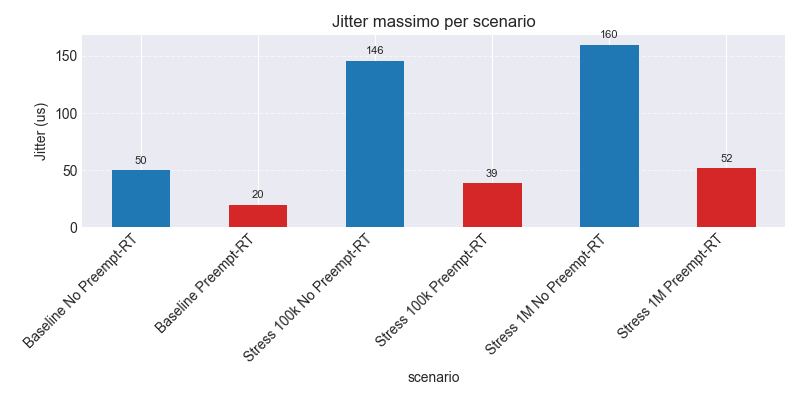

In [7]:

# Jitter massimo per scenario (colori: blu No Preempt-RT, rosso Preempt-RT)
if summary_df.empty:
    print('Nessun dato disponibile per il jitter')
else:
    label_to_key = thread_df[['scenario','scenario_key']].drop_duplicates().set_index('scenario')['scenario_key']
    def color_for(sc):
        key = label_to_key.get(sc, '')
        if 'nopreempt_rt' in key:
            return 'tab:blue'
        if 'preempt_rt' in key:
            return 'tab:red'
        return 'gray'
    colors = [color_for(sc) for sc in summary_df['scenario']]

    fig, ax = plt.subplots(figsize=(8, 4))
    summary_df.set_index('scenario')['jitter'].plot(kind='bar', ax=ax, color=colors)
    ax.set_ylabel('Jitter (us)')
    ax.set_title('Jitter massimo per scenario')
    ax.grid(True, axis='y', linestyle='--', alpha=0.6)
    for container in ax.containers:
        ax.bar_label(container, fmt='%.0f', padding=3, fontsize=8)
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()


/var/folders/_p/b2z7my2j6kv8pq069jgcn4zh0000gn/T/ipykernel_33969/3717790754.py:25: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=ordered, patch_artist=True)


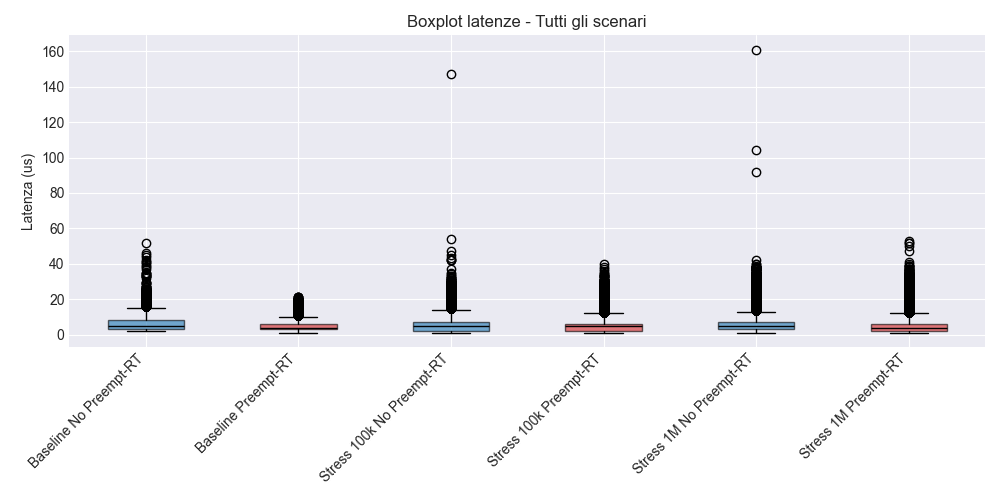

In [8]:

# Boxplot delle latenze separati: No Preempt-RT vs Preempt-RT (colori coerenti)
if latency_df.empty:
    print('Nessuna latenza disponibile per i boxplot')
else:
    label_to_key = thread_df[['scenario','scenario_key']].drop_duplicates().set_index('scenario')['scenario_key']

    def color_for(sc):
        key = label_to_key.get(sc, '')
        if 'nopreempt_rt' in key:
            return 'tab:blue'
        if 'preempt_rt' in key:
            return 'tab:red'
        return 'gray'

    def plot_group(labels, title):
        if len(labels) == 0:
            print(f'Nessun scenario per {title}')
            return
        subset = latency_df[latency_df['scenario'].isin(labels)]
        ordered = subset['scenario'].unique()
        data = [subset[subset['scenario']==sc]['latency'] for sc in ordered]
        colors = [color_for(sc) for sc in ordered]

        fig, ax = plt.subplots(figsize=(10, 5))
        bp = ax.boxplot(data, labels=ordered, patch_artist=True)
        for patch, c in zip(bp['boxes'], colors):
            patch.set_facecolor(c)
            patch.set_alpha(0.6)
        for median in bp['medians']:
            median.set_color('black')
        ax.set_ylabel('Latenza (us)')
        ax.set_title(title)
        plt.xticks(rotation=45, ha='right')
        plt.tight_layout()
        plt.show()

    #plot_group(nopre, 'Boxplot latenze - No Preempt-RT')
    #plot_group(pre, 'Boxplot latenze - Preempt-RT')
    plot_group(label_to_key.index, 'Boxplot latenze - Tutti gli scenari')


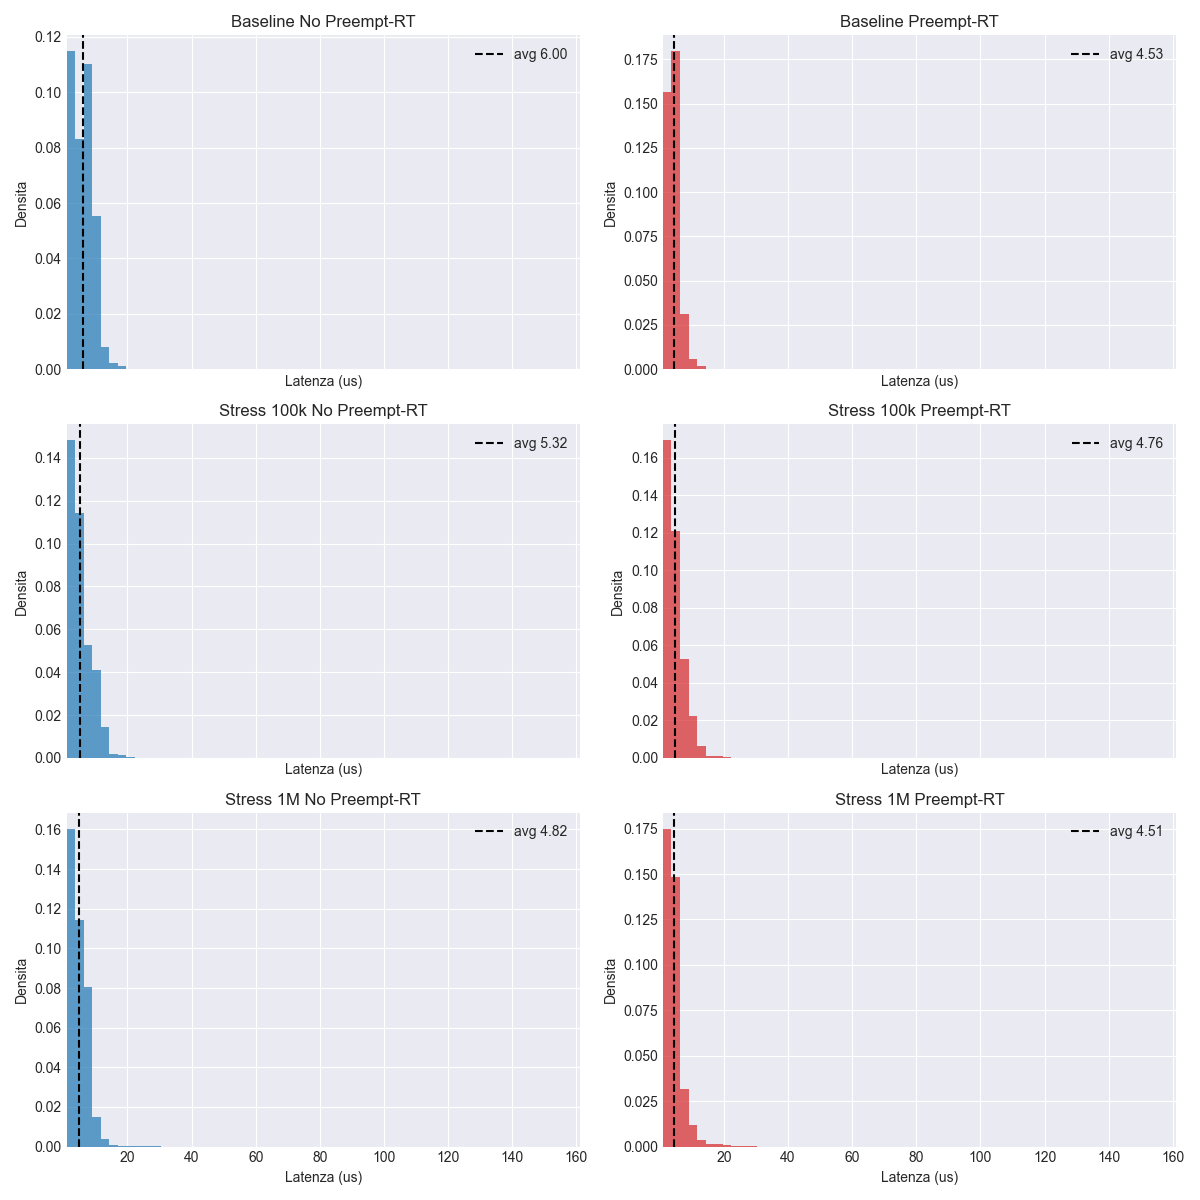

In [9]:

# Distribuzione delle latenze per scenario (colori coerenti, stessa scala X per confronto)
if latency_df.empty:
    print('Nessuna latenza disponibile per le distribuzioni')
else:
    label_to_key = thread_df[['scenario','scenario_key']].drop_duplicates().set_index('scenario')['scenario_key']
    def color_for(sc):
        key = label_to_key.get(sc, '')
        if 'nopreempt_rt' in key:
            return 'tab:blue'
        if 'preempt_rt' in key:
            return 'tab:red'
        return 'gray'

    scenarios = latency_df['scenario'].unique()
    global_min = latency_df['latency'].min()
    global_max = latency_df['latency'].max()
    bins = np.linspace(global_min, global_max, 61)  # 60 intervalli comuni a tutti

    n = len(scenarios)
    cols = 2
    rows = (n + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(12, 4 * rows), sharex=True)
    axes = axes.flat if n > 1 else [axes]
    for ax, sc in zip(axes, scenarios):
        data = latency_df[latency_df.scenario == sc].latency
        color = color_for(sc)
        ax.hist(data, bins=bins, density=True, alpha=0.7, color=color)
        ax.axvline(data.mean(), color='black', linestyle='--', label=f"avg {data.mean():.2f}")
        ax.set_title(sc)
        ax.set_xlabel('Latenza (us)')
        ax.set_ylabel('Densita')
        ax.set_xlim(global_min, global_max)
        ax.legend()
    for ax in axes[n:]:
        ax.set_visible(False)
    plt.tight_layout()
    plt.show()


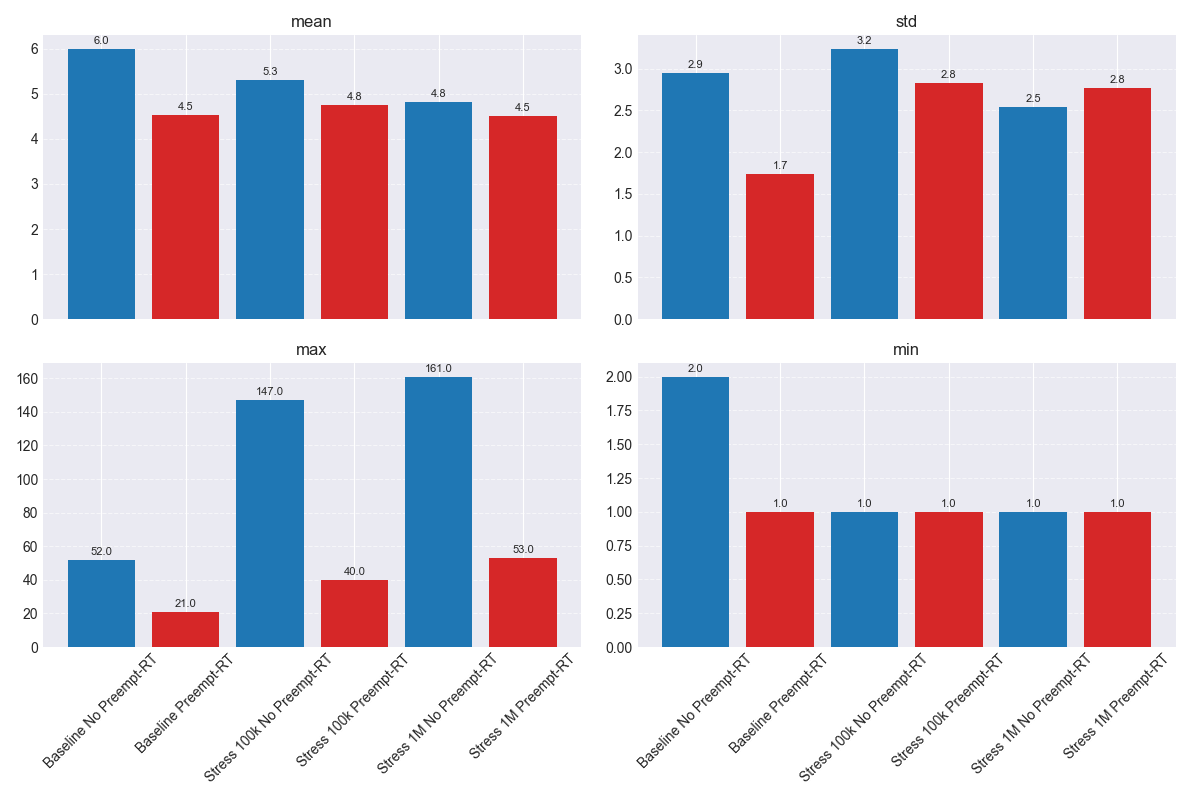

In [ ]:

# Grafico riassuntivo: media, deviazione standard, max, min (colori coerenti per scenario)
label_to_key = thread_df[['scenario','scenario_key']].drop_duplicates().set_index('scenario')['scenario_key']

def color_for(sc):
    key = label_to_key.get(sc, '')
    if 'nopreempt_rt' in key:
        return 'tab:blue'
    if 'preempt_rt' in key:
        return 'tab:red'
    return 'gray'

colors = [color_for(sc) for sc in summary_df['scenario']]

fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex=True)
metrics = ['mean', 'std', 'max', 'min']
for metric, ax in zip(metrics, axes.flat):
    ax.bar(summary_df['scenario'], summary_df[metric], color=colors)
    for container in ax.containers:
        ax.bar_label(container, fmt='%.1f', padding=2, fontsize=8)
    ax.set_title(metric)
    ax.grid(True, axis='y', linestyle='--', alpha=0.6)
    ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()


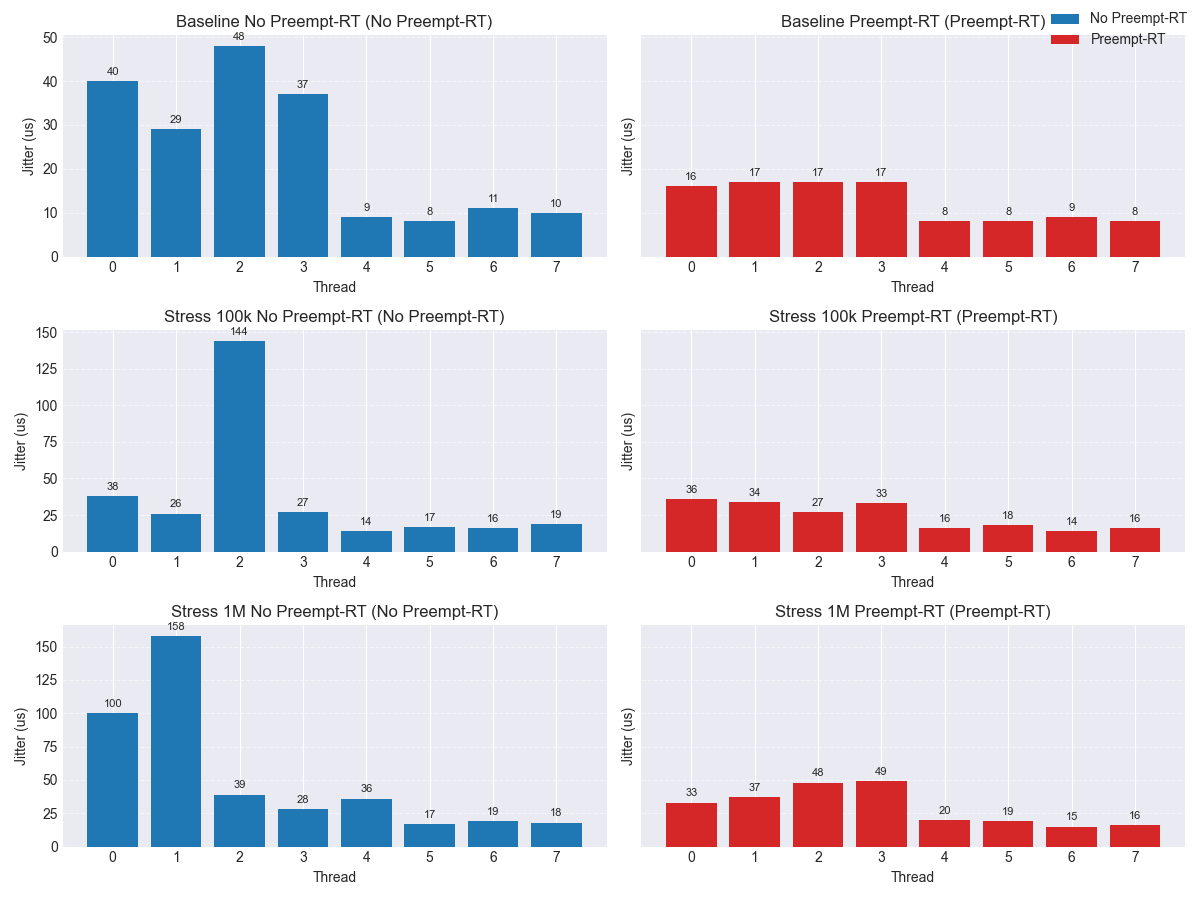

In [11]:

# Jitter per thread in ogni scenario (coppie affiancate: No Preempt-RT a sinistra, Preempt-RT a destra)
if thread_df.empty:
    print('Nessun dato thread disponibile')
else:
    from matplotlib.patches import Patch

    label_key_df = thread_df[['scenario','scenario_key']].drop_duplicates()

    pairs = {}
    for _, row in label_key_df.iterrows():
        label = row['scenario']
        key = row['scenario_key']
        if key.endswith('_nopreempt_rt'):
            base = key.replace('_nopreempt_rt', '')
            pairs.setdefault(base, {})['nopre'] = (label, key)
        elif key.endswith('_preempt_rt'):
            base = key.replace('_preempt_rt', '')
            pairs.setdefault(base, {})['pre'] = (label, key)
        else:
            pairs.setdefault(key, {})['other'] = (label, key)

    ordered_bases = list(pairs.keys())
    color_map = {'nopre': 'tab:blue', 'pre': 'tab:red'}

    fig, axes = plt.subplots(len(ordered_bases), 2, figsize=(12, 3 * len(ordered_bases)), sharey='row', squeeze=False)

    for row_idx, base in enumerate(ordered_bases):
        for col_idx, kind in enumerate(['nopre', 'pre']):
            ax = axes[row_idx, col_idx]
            entry = pairs[base].get(kind)
            if entry is None:
                ax.axis('off')
                continue
            label, key = entry
            tsub = thread_df[thread_df['scenario_key'] == key]
            bars = ax.bar(tsub['thread'], tsub['jitter'], color=color_map.get(kind, 'gray'))
            ax.bar_label(bars, fmt='%.0f', padding=3, fontsize=8)
            title_suffix = 'No Preempt-RT' if kind=='nopre' else 'Preempt-RT'
            ax.set_title(f'{label} ({title_suffix})')
            ax.set_ylabel('Jitter (us)')
            ax.set_xlabel('Thread')
            ax.grid(True, axis='y', linestyle='--', alpha=0.6)

    handles = [Patch(facecolor=color_map['nopre'], label='No Preempt-RT'),
               Patch(facecolor=color_map['pre'], label='Preempt-RT')]
    fig.legend(handles=handles, loc='upper right', frameon=False)

    plt.tight_layout()
    plt.show()
